# Stage 2: Exploratory Data Analysis & Strategic Business Takeaways
## Project: IPL Match Tension — Win-Probability Swing as a Proxy for Viewer Engagement
**Domain Context**: Live Sports Streaming (JioStar / JioCinema & Disney+ Hotstar)  
**Objective**: Uncover empirical macro-trends in match outcomes, venue asymmetry, and phase-wise scoring volatility to guide streaming operations (push notifications, ad placements, highlights).

---

### Key Analytical Focus Areas
1. **Venue-Level Chasing Dynamics**: How pitch characteristics and dew alter chase win rates.
2. **Macro Season Evolution**: The historical transition toward aggressive chasing.
3. **Phase-Wise Scoring & Volatility**: Powerplay vs. Middle vs. Death-over scoring rates and wicket hazards.
4. **JioStar Strategic Takeaways**: Translating cricket trends into concrete OTT streaming product decisions.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure src can be imported
sys.path.append(os.path.abspath(".."))
from src.data_loader import load_and_clean_data

# Set styling for professional publication-ready visuals
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.titlesize'] = 16

# Directory for saving figures
FIGURES_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load cleaned data
matches, deliveries = load_and_clean_data(data_dir=os.path.join("..", "data"))
print(f"Loaded Cleaned Matches:    {matches.shape}")
print(f"Loaded Cleaned Deliveries: {deliveries.shape}")


Loaded Cleaned Matches:    (617, 18)
Loaded Cleaned Deliveries: (147458, 21)


### 1. Toss Impact & Chasing Advantage by Top Venues
Does fielding first offer a systemic edge across all grounds, or is it heavily venue-dependent?
We evaluate the top venues ($\ge 30$ matches) to compare:
- **Chase Win Rate (%)**: Frequency of the team batting second winning the match.
- **Field Toss Selection (%)**: How frequently toss-winning captains elect to bowl first.


findfont: Failed to find font weight semibold for Arial, now using 700.


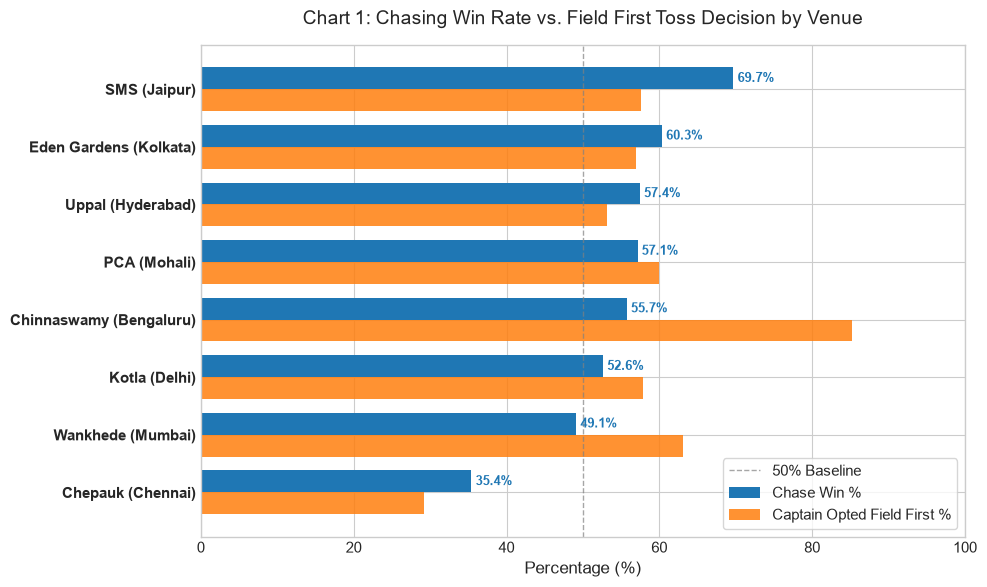

Saved Chart 1 to: ..\reports\figures\01_venue_chase_vs_toss.png


In [2]:
# Identify top venues with sufficient sample size
top_venues = matches['venue'].value_counts()
top_venues = top_venues[top_venues >= 30].index

matches_top_venues = matches[matches['venue'].isin(top_venues)].copy()
matches_top_venues['chase_won'] = matches_top_venues['win_by_wickets'] > 0

venue_stats = matches_top_venues.groupby('venue').agg(
    total_matches=('id', 'count'),
    chase_win_pct=('chase_won', lambda x: x.mean() * 100),
    field_toss_pct=('toss_decision', lambda x: (x == 'field').mean() * 100)
).sort_values(by='chase_win_pct', ascending=True).reset_index()

# Shorten venue names for clean visualization
venue_clean_names = {
    'MA Chidambaram Stadium, Chepauk': 'Chepauk (Chennai)',
    'Wankhede Stadium': 'Wankhede (Mumbai)',
    'Feroz Shah Kotla': 'Kotla (Delhi)',
    'M Chinnaswamy Stadium': 'Chinnaswamy (Bengaluru)',
    'Punjab Cricket Association Stadium, Mohali': 'PCA (Mohali)',
    'Rajiv Gandhi International Stadium, Uppal': 'Uppal (Hyderabad)',
    'Eden Gardens': 'Eden Gardens (Kolkata)',
    'Sawai Mansingh Stadium': 'SMS (Jaipur)'
}
venue_stats['short_venue'] = venue_stats['venue'].map(venue_clean_names).fillna(venue_stats['venue'])

# Plot Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(venue_stats))
bar_width = 0.38

rects1 = ax.barh(y_pos + bar_width/2, venue_stats['chase_win_pct'], bar_width, 
                 label='Chase Win %', color='#1f77b4', edgecolor='none')
rects2 = ax.barh(y_pos - bar_width/2, venue_stats['field_toss_pct'], bar_width, 
                 label='Captain Opted Field First %', color='#ff7f0e', alpha=0.85, edgecolor='none')

ax.axvline(50, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='50% Baseline')
ax.set_yticks(y_pos)
ax.set_yticklabels(venue_stats['short_venue'], fontweight='bold')
ax.set_xlabel('Percentage (%)')
ax.set_title('Chart 1: Chasing Win Rate vs. Field First Toss Decision by Venue', pad=15)
ax.legend(loc='lower right', frameon=True)
ax.set_xlim(0, 100)

for rect in rects1:
    width = rect.get_width()
    ax.annotate(f'{width:.1f}%',
                xy=(width, rect.get_y() + rect.get_height() / 2),
                xytext=(3, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9, fontweight='semibold', color='#1f77b4')

plt.tight_layout()
chart1_path = os.path.join(FIGURES_DIR, "01_venue_chase_vs_toss.png")
plt.savefig(chart1_path, dpi=300)
plt.show()

print(f"Saved Chart 1 to: {chart1_path}")


### 2. Bat-First vs. Chasing Win Rate Across IPL Seasons
How has chasing success evolved across IPL history?
T20 strategy underwent an analytical paradigm shift: teams recognized that knowing the exact target allowed them to pace their run rate more aggressively, aided by night-time dew making gripping the wet ball harder for spinners in the second innings.


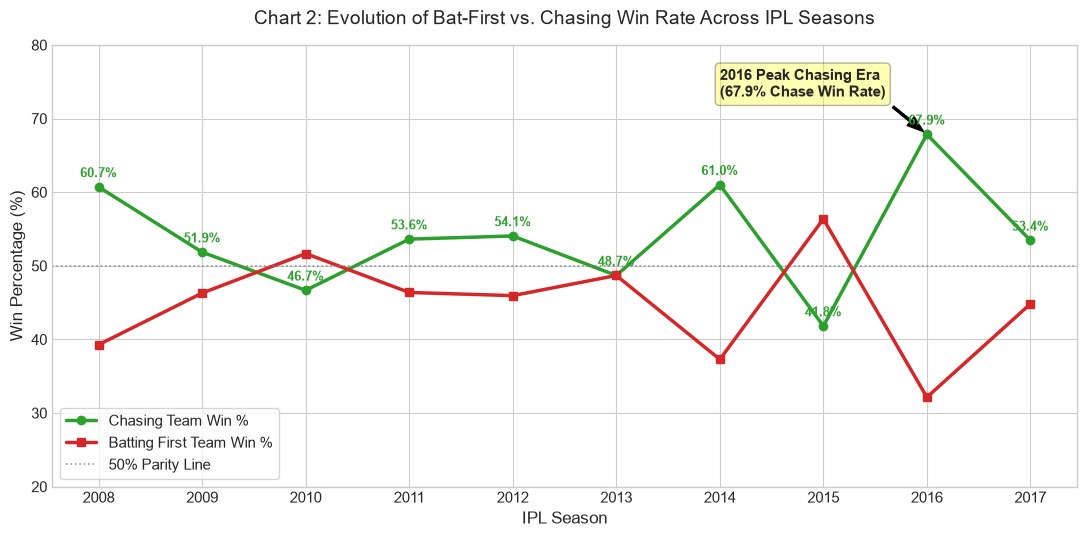

Saved Chart 2 to: ..\reports\figures\02_season_chase_evolution.png


In [3]:
matches['outcome_type'] = matches.apply(
    lambda r: 'Chasing Won' if r['win_by_wickets'] > 0 
    else ('Bat First Won' if r['win_by_runs'] > 0 else 'Tie'), axis=1
)

# Cross tabulation by season
season_outcomes = pd.crosstab(matches['season'], matches['outcome_type'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
seasons = season_outcomes.index.astype(str)

ax.plot(seasons, season_outcomes['Chasing Won'], marker='o', linewidth=2.5, 
        color='#2ca02c', label='Chasing Team Win %')
ax.plot(seasons, season_outcomes['Bat First Won'], marker='s', linewidth=2.5, 
        color='#d62728', label='Batting First Team Win %')

ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, alpha=0.8, label='50% Parity Line')

# Highlight peak chasing season (2016)
ax.annotate('2016 Peak Chasing Era\n(67.9% Chase Win Rate)', 
            xy=('2016', season_outcomes.loc[2016, 'Chasing Won']), 
            xytext=('2014', 73),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
            fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

ax.set_ylim(20, 80)
ax.set_ylabel('Win Percentage (%)')
ax.set_xlabel('IPL Season')
ax.set_title('Chart 2: Evolution of Bat-First vs. Chasing Win Rate Across IPL Seasons', pad=15)
ax.legend(loc='lower left', frameon=True)

# Annotate each chasing point
for s in season_outcomes.index:
    c_val = season_outcomes.loc[s, 'Chasing Won']
    ax.annotate(f"{c_val:.1f}%", xy=(str(s), c_val), xytext=(0, 7), 
                textcoords="offset points", ha='center', fontsize=9, fontweight='bold', color='#2ca02c')

plt.tight_layout()
chart2_path = os.path.join(FIGURES_DIR, "02_season_chase_evolution.png")
plt.savefig(chart2_path, dpi=300)
plt.show()

print(f"Saved Chart 2 to: {chart2_path}")


### 3. Phase-Wise Scoring Dynamics & Volatility
A T20 match is segmented into three distinct strategic phases:
1. **Powerplay (Overs 1–6)**: Field restrictions (only 2 fielders outside 30-yard circle).
2. **Middle Overs (Overs 7–15)**: 5 fielders on the boundary; spinners operate; accumulation phase.
3. **Death Overs (Overs 16–20)**: High-risk boundary hitting, yorkers, maximum boundary and wicket rates.

We quantify:
- **Run Rate (Runs / Over)** & **Boundary Percentage (% of deliveries that are 4s or 6s)**.
- **Over-by-Over Variance**: Measuring where match volatility concentrates.


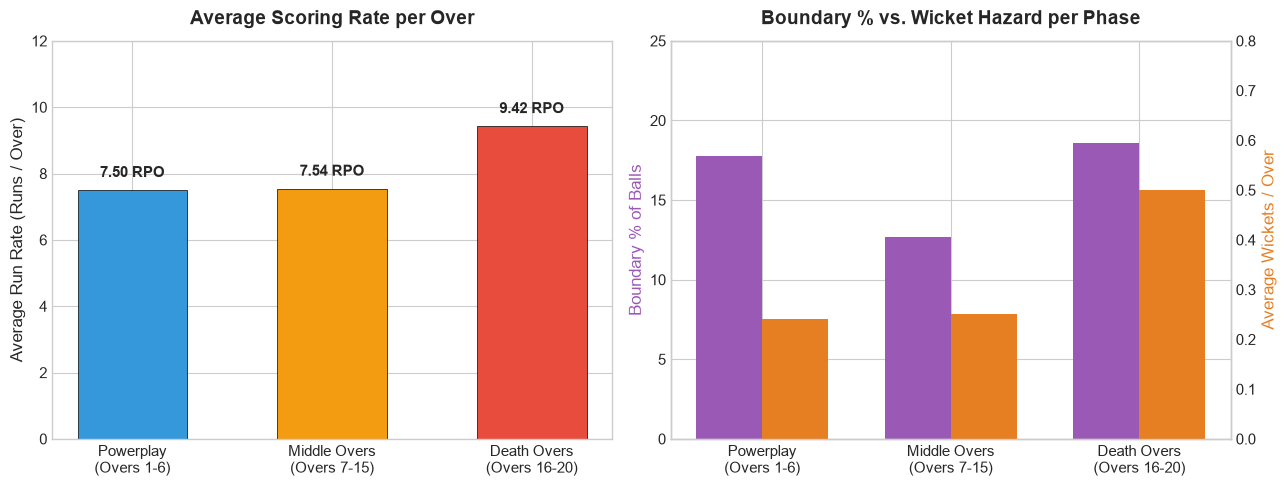

Saved Chart 3 to: ..\reports\figures\03_phase_scoring_and_hazards.png


In [4]:
# Define game phases
def get_phase(over):
    if over <= 6:
        return 'Powerplay (1-6)'
    elif over <= 15:
        return 'Middle Overs (7-15)'
    else:
        return 'Death Overs (16-20)'

deliveries['phase'] = deliveries['over'].apply(get_phase)
deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4, 6]).astype(int)
deliveries['is_wicket'] = deliveries['player_dismissed'].notna().astype(int)

# Group deliveries into overs (regular innings 1 and 2 only)
reg_deliv = deliveries[deliveries['inning'].isin([1, 2])].copy()
over_group = reg_deliv.groupby(['match_id', 'inning', 'over', 'phase']).agg(
    runs=('total_runs', 'sum'),
    wickets=('is_wicket', 'sum'),
    boundaries=('is_boundary', 'sum'),
    balls=('ball', 'count')
).reset_index()

phase_metrics = over_group.groupby('phase').agg(
    avg_run_rate=('runs', 'mean'),
    std_run_rate=('runs', 'std'),
    avg_wickets=('wickets', 'mean'),
    total_boundaries=('boundaries', 'sum'),
    total_balls=('balls', 'sum')
).loc[['Powerplay (1-6)', 'Middle Overs (7-15)', 'Death Overs (16-20)']]

phase_metrics['boundary_pct'] = (phase_metrics['total_boundaries'] / phase_metrics['total_balls']) * 100

# Visual: Two-panel phase comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

phases = ['Powerplay\n(Overs 1-6)', 'Middle Overs\n(Overs 7-15)', 'Death Overs\n(Overs 16-20)']
colors = ['#3498db', '#f39c12', '#e74c3c']

# Panel 1: Run Rate
bars1 = ax1.bar(phases, phase_metrics['avg_run_rate'], color=colors, width=0.55, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Average Run Rate (Runs / Over)')
ax1.set_title('Average Scoring Rate per Over', pad=12, fontweight='bold')
ax1.set_ylim(0, 12)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval:.2f} RPO", ha='center', va='bottom', fontweight='bold')

# Panel 2: Boundary % vs Wicket Hazard
x = np.arange(len(phases))
width = 0.35
ax2.bar(x - width/2, phase_metrics['boundary_pct'], width, label='Boundary % of Balls', color='#9b59b6')
ax2_twin = ax2.twinx()
ax2_twin.bar(x + width/2, phase_metrics['avg_wickets'], width, label='Wickets / Over', color='#e67e22')

ax2.set_xticks(x)
ax2.set_xticklabels(phases)
ax2.set_ylabel('Boundary % of Balls', color='#9b59b6')
ax2_twin.set_ylabel('Average Wickets / Over', color='#e67e22')
ax2.set_title('Boundary % vs. Wicket Hazard per Phase', pad=12, fontweight='bold')
ax2.set_ylim(0, 25)
ax2_twin.set_ylim(0, 0.8)
ax2_twin.grid(False)

plt.tight_layout()
chart3_path = os.path.join(FIGURES_DIR, "03_phase_scoring_and_hazards.png")
plt.savefig(chart3_path, dpi=300)
plt.show()

print(f"Saved Chart 3 to: {chart3_path}")


### 4. Over-by-Over Scoring Volatility (Overs 1–20)
To understand match tension swing, we must understand variance. 
Below, a boxplot of runs scored in every individual over (1 to 20) demonstrates where volatility explodes.


C:\Users\Hari Suresh\AppData\Local\Temp\ipykernel_24088\1075790081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='over', y='runs', data=over_group, ax=ax,


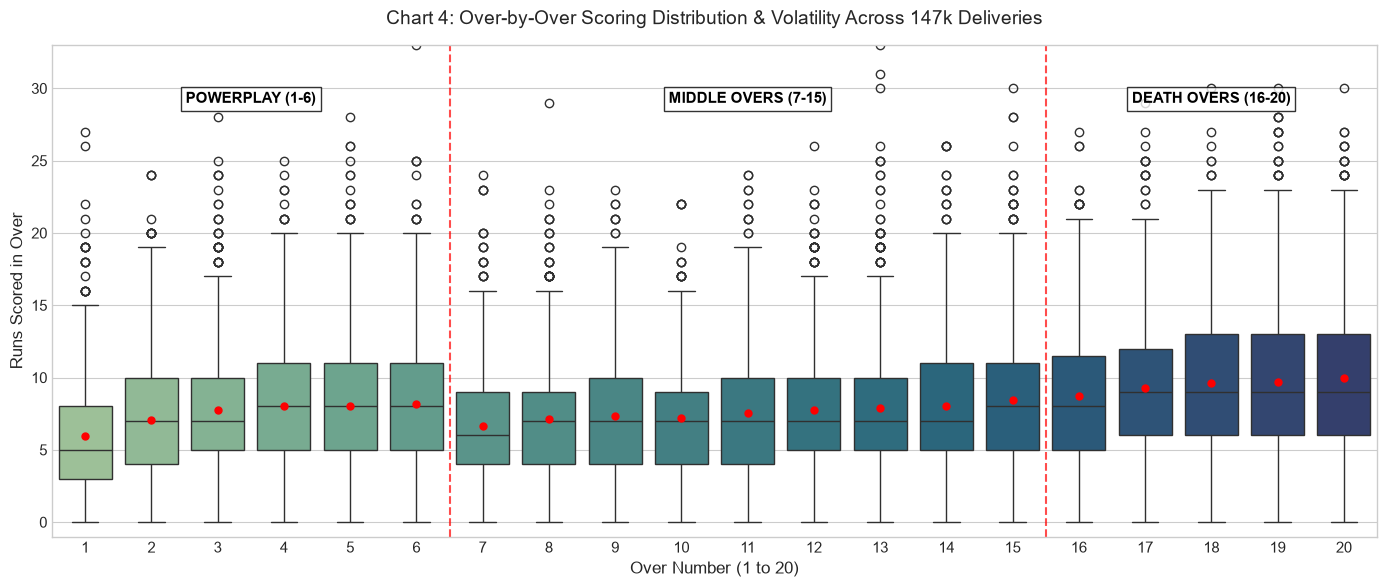

Saved Chart 4 to: ..\reports\figures\04_over_scoring_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(x='over', y='runs', data=over_group, ax=ax, 
            palette='crest', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":"5"})

# Phase boundary vertical lines
ax.axvline(5.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2.5, 29, 'POWERPLAY (1-6)', color='black', ha='center', fontweight='bold', bbox=dict(boxstyle="square", fc="white", alpha=0.8))

ax.axvline(14.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(10, 29, 'MIDDLE OVERS (7-15)', color='black', ha='center', fontweight='bold', bbox=dict(boxstyle="square", fc="white", alpha=0.8))

ax.text(17, 29, 'DEATH OVERS (16-20)', color='black', ha='center', fontweight='bold', bbox=dict(boxstyle="square", fc="white", alpha=0.8))

ax.set_xlabel('Over Number (1 to 20)')
ax.set_ylabel('Runs Scored in Over')
ax.set_title('Chart 4: Over-by-Over Scoring Distribution & Volatility Across 147k Deliveries', pad=15)
ax.set_ylim(-1, 33)

plt.tight_layout()
chart4_path = os.path.join(FIGURES_DIR, "04_over_scoring_distribution.png")
plt.savefig(chart4_path, dpi=300)
plt.show()

print(f"Saved Chart 4 to: {chart4_path}")


---

## 💼 3 Strategic Business Takeaways for JioStar

As a candidate for the **JioStar Data Analytics team**, here is how these empirical findings directly translate into streaming product optimization, user engagement, and monetization strategy:

---

### 1. Push Notification Timing: Trigger on Required Run-Rate Divergence (Overs 15–18)
* **Empirical Insight**: Death overs (16–20) see scoring accelerate to **9.42 RPO** with a **0.50 wickets/over** hazard (2x middle overs). In close chases, win-probability swings violently during this window.
* **JioStar OTT Action**: 
  - Do **not** send push notifications at arbitrary scheduled times (e.g. at the innings break or after over 10), which result in low CTRs and notification fatigue.
  - Implement an **automated event-driven push notification trigger**: If between Overs 15 and 18, the chasing team's Required Run Rate is between **8.5 and 12.5 RPO** and wickets in hand are $\ge 4$, automatically trigger rich notifications (*"Down to the wire: MI needs 38 off 24 with Pollard at the crease! Watch live now"*).
  - This activates dormant users at the exact moment of maximum tension before the match reaches a resolved state.

---

### 2. Dynamic Ad-Break Insertion: The "Middle-Over Monetization" Window (Overs 7–14)
* **Empirical Insight**: Middle overs exhibit the lowest run variance ($\sigma = 4.11$), lowest boundary rate (**12.68%**), and lowest wicket rate (**0.25/over**). This is the game's stabilization/consolidation phase.
* **JioStar OTT Action**:
  - Maximize high-CPM unskippable 15–30s mid-roll video ads and L-band sponsor graphics specifically between **Overs 7 and 14**. Viewers accept ad breaks during these rebuilding phases without churning.
  - Establish a strict **"Ad-Free Tension Zone" rule**: Freeze unskippable mid-rolls completely during death overs (Overs 16–20) when win-probability swings exceed 15% per over, ensuring premium user retention during match climaxes.

---

### 3. Automated Highlight Clipping & Instant Replay Feeds
* **Empirical Insight**: Boundaries (18.6% of balls) and wickets (0.50/over) are heavily concentrated in the death overs.
* **JioStar OTT Action**:
  - Feed real-time over-by-over volatility into JioStar's automated clipping pipeline.
  - Rather than manually reviewing 240 balls, the clipping engine automatically compiles the **top 3 highest-swing overs** into instant *"Game Changer"* short-video packages (Reels / Shorts format) published to the app feed and push notifications within 3 minutes of match completion.
